# 🌸 Iris Flower Classification

### OASIS INFOBYTE — Data Science Internship
### Task 1 — Iris Flower Classification

---

## 📌 Project Overview

This project focuses on building a machine learning classification system
that can identify the species of an Iris flower based on its physical
measurements.

The Iris dataset contains observations from three Iris species:

- **Iris Setosa**
- **Iris Versicolor**
- **Iris Virginica**

Each observation contains four numerical measurements:

- Sepal Length
- Sepal Width
- Petal Length
- Petal Width

The project follows a complete machine learning workflow, starting with
dataset exploration and exploratory data analysis (EDA), followed by
visualization, feature analysis, model training, evaluation, comparison,
and selection of the best-performing classification model.

## 🎯 Project Objectives

1. Load the Iris dataset using Scikit-learn.
2. Understand the structure and characteristics of the dataset.
3. Perform exploratory data analysis (EDA).
4. Check data types, missing values, duplicates, and descriptive statistics.
5. Visualize relationships between numerical features.
6. Analyze feature distributions using box plots.
7. Discuss the importance of features for classification.
8. Split the dataset into training and testing sets.
9. Train multiple classification algorithms.
10. Evaluate the models using accuracy, precision, recall, and F1-score.
11. Analyze confusion matrices and classification reports.
12. Compare the trained models and identify the best classifier.

## 🛠️ Technologies Used

- **Python**
- **Pandas**
- **NumPy**
- **Matplotlib**
- **Seaborn**
- **Scikit-learn**
- **Jupyter Notebook**

---

In [1]:
# ============================================================
# Iris Flower Classification
# OASIS INFOBYTE - Data Science Internship
# Task 1
# ============================================================

# Import numerical computing library
import numpy as np

# Import data manipulation library
import pandas as pd

# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Import Iris dataset
from sklearn.datasets import load_iris

# Import machine learning utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Import classification algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

# Import evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# Suppress unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

# Configure visualization appearance
sns.set_theme(style="whitegrid")

print("All required libraries imported successfully.")

All required libraries imported successfully.


## 1. Loading the Dataset

The Iris dataset is loaded directly from the Scikit-learn library using
the `load_iris()` function.

This dataset is suitable for demonstrating a supervised classification
workflow because the observations already have known species labels.

The dataset contains four numerical input features and one target variable
representing the Iris species.

In [2]:
# Load the built-in Iris dataset
iris = load_iris()

# Create a DataFrame using the feature data
df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

# Add the numerical target
df["target"] = iris.target

# Convert numerical target values into readable species names
df["species"] = df["target"].map(
    dict(enumerate(iris.target_names))
)

# Display the first five observations
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


## 2. Dataset Inspection

Before performing detailed exploratory data analysis, we inspect the
dataset to understand:

- Number of observations and features
- Data types
- Missing values
- Duplicate records
- Descriptive statistics
- Distribution of the target classes

This initial inspection helps determine whether the dataset requires
data-cleaning operations before model development.

In [3]:
# Display dataset dimensions
print("Dataset Shape:", df.shape)

# Display data types of each column
print("\nData Types:")
print(df.dtypes)

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Check for duplicate rows
print("\nDuplicate Rows:", df.duplicated().sum())

# Display descriptive statistics
print("\nDescriptive Statistics:")
display(df.describe())

Dataset Shape: (150, 6)

Data Types:
sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
target                 int64
species                  str
dtype: object

Missing Values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
species              0
dtype: int64

Duplicate Rows: 1

Descriptive Statistics:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [4]:
# Display the number of observations in each species
species_distribution = df["species"].value_counts()

print("Species Distribution:")
print(species_distribution)

Species Distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


## 3. Exploratory Data Analysis (EDA)

Exploratory Data Analysis helps us understand the distribution of the
features and identify relationships between the variables before training
machine learning models.

The analysis will include:

- Feature distributions
- Species-wise feature comparison
- Pairwise relationships between features
- Box plots for detecting differences and potential outliers
- Correlation analysis

These visualizations will help us determine which measurements provide
the strongest separation between the three Iris species.

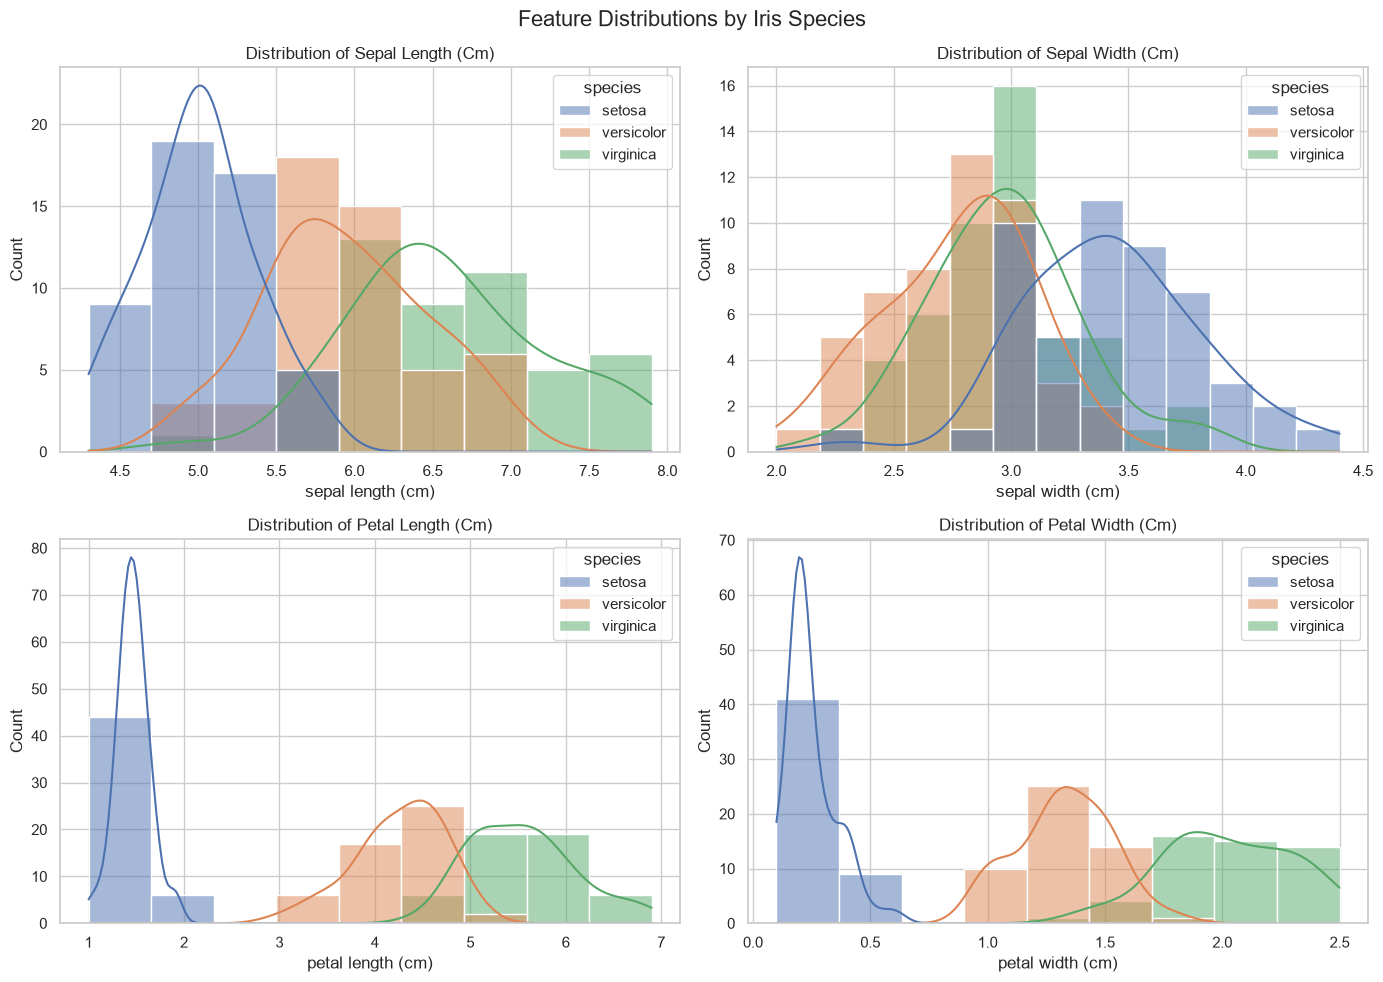

In [5]:
# Select numerical features
features = iris.feature_names

# Create distribution plots for each feature
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, feature in zip(axes.flat, features):
    sns.histplot(
        data=df,
        x=feature,
        hue="species",
        kde=True,
        ax=ax
    )
    ax.set_title(f"Distribution of {feature.title()}")

plt.suptitle("Feature Distributions by Iris Species", fontsize=16)
plt.tight_layout()
plt.show()

### Observation

The feature distributions show that the Iris species do not have identical
measurement patterns.

In particular, petal-related measurements show clearer differences between
the species than many of the sepal measurements. This suggests that petal
length and petal width may be particularly useful for distinguishing the
Iris species.

## 4. Pairwise Feature Relationships

A pairplot is used to visualize relationships between every pair of
numerical features while also showing the distribution of individual
features.

The species are represented separately so that we can visually examine
whether different classes form distinct clusters.

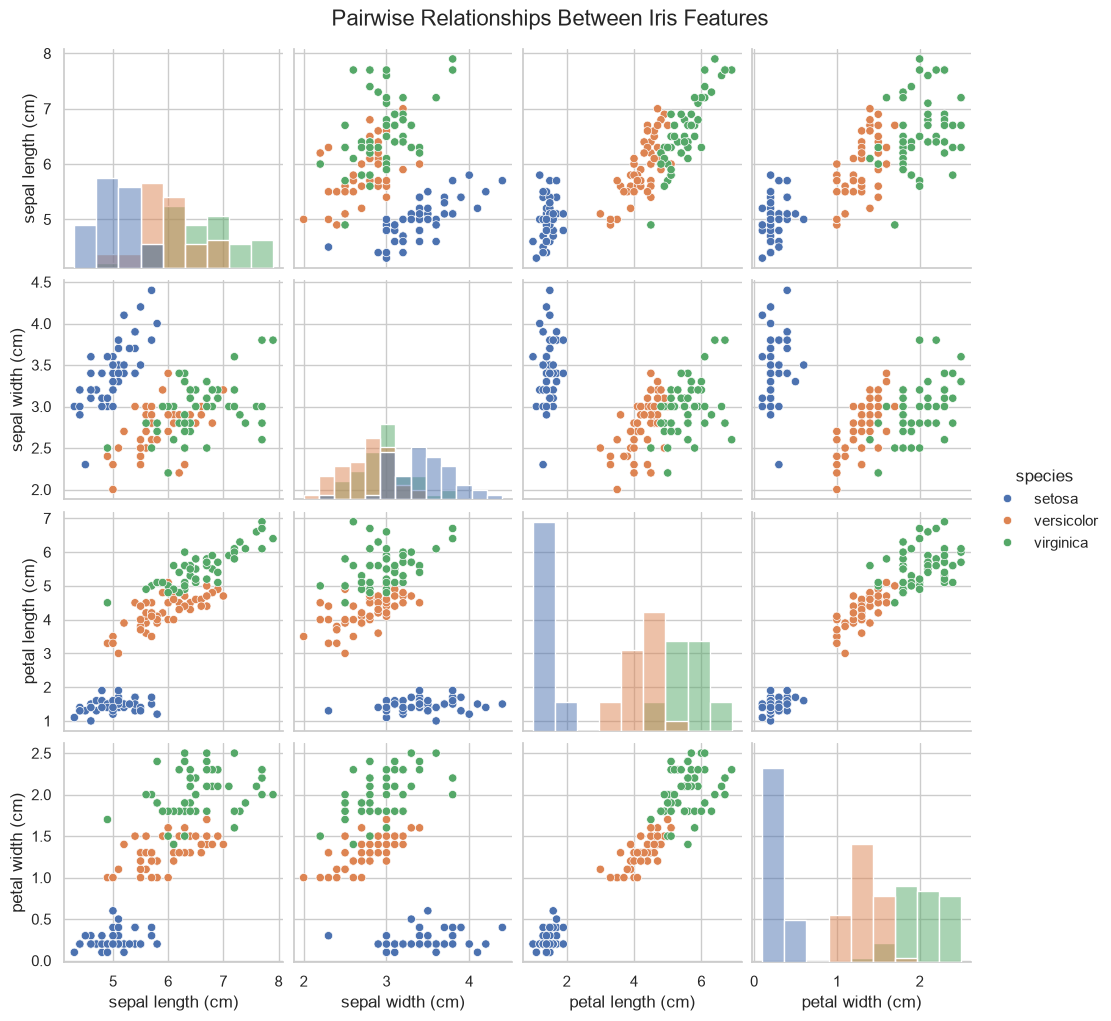

In [6]:
# Create a pairplot for the Iris features
sns.pairplot(
    df,
    vars=iris.feature_names,
    hue="species",
    diag_kind="hist"
)

plt.suptitle(
    "Pairwise Relationships Between Iris Features",
    y=1.02,
    fontsize=16
)

plt.show()

### Observation

The pairplot shows that **petal length and petal width provide strong
separation between the Iris species**.

Iris Setosa forms a clearly separated cluster, while Versicolor and
Virginica show some overlap in certain measurements.

The strong separation observed in petal-related features indicates that
these features are likely to be highly informative for classification.

## 5. Feature Distribution Using Box Plots

Box plots are used to compare the distribution of each numerical feature
across the three Iris species.

They allow us to examine:

- Median values
- Spread of the data
- Differences between species
- Potential outliers

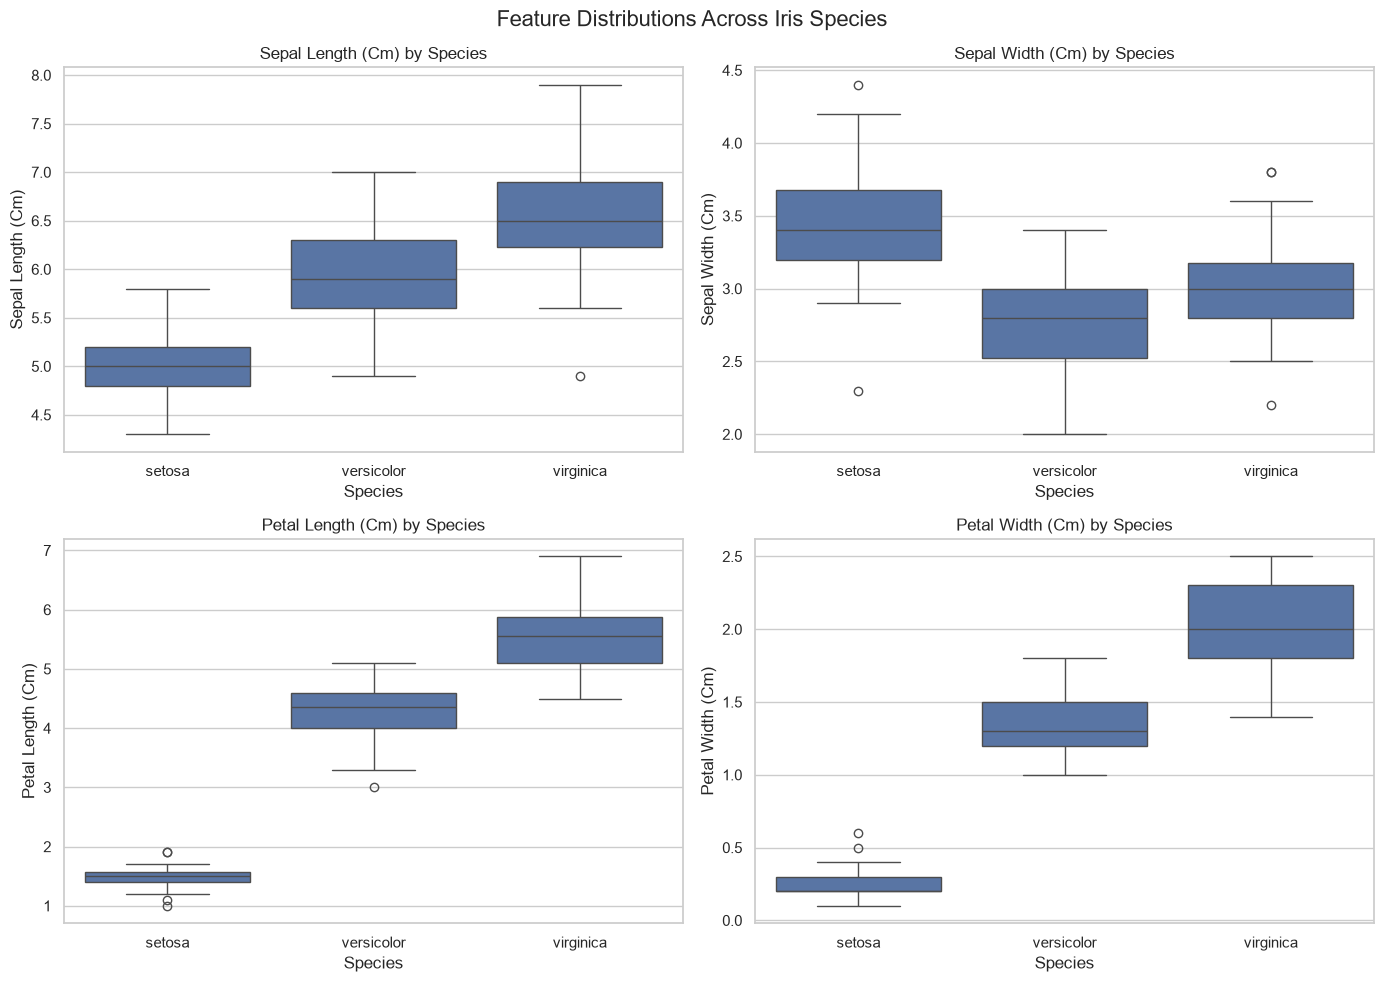

In [7]:
# Create box plots for each numerical feature
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, feature in zip(axes.flat, iris.feature_names):
    sns.boxplot(
        data=df,
        x="species",
        y=feature,
        ax=ax
    )
    
    ax.set_title(f"{feature.title()} by Species")
    ax.set_xlabel("Species")
    ax.set_ylabel(feature.title())

plt.suptitle("Feature Distributions Across Iris Species", fontsize=16)
plt.tight_layout()
plt.show()

### Observation

The box plots demonstrate noticeable differences in feature distributions
among the three species.

Petal length and petal width show particularly strong differences between
the species, making them potentially more useful for classification.

Some overlap exists between Versicolor and Virginica, indicating that these
two species may be more difficult to distinguish than Setosa.

## 6. Feature Correlation Analysis

Correlation analysis measures the strength and direction of linear
relationships between numerical features.

A heatmap is used to make these relationships easier to interpret.

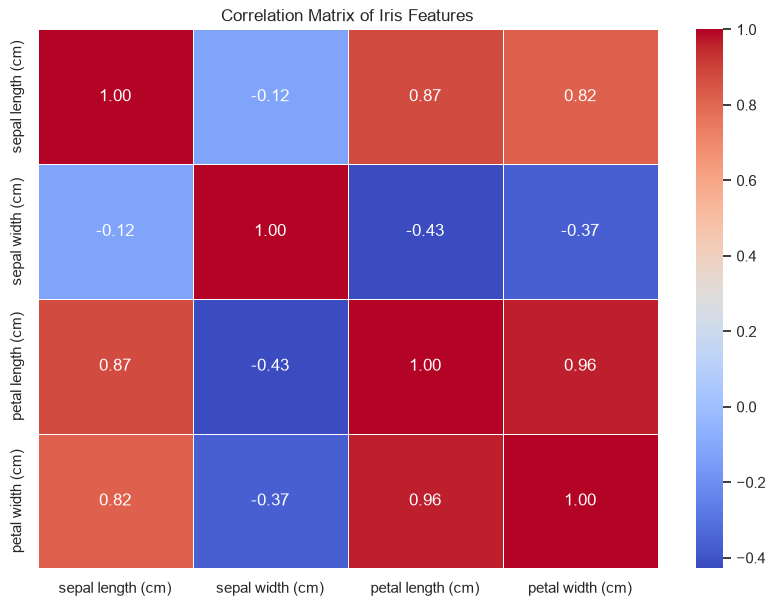

In [8]:
# Calculate correlation matrix for numerical features
correlation_matrix = df[iris.feature_names].corr()

# Plot correlation heatmap
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix of Iris Features")
plt.show()

### Observation

The correlation analysis indicates that some Iris measurements have strong
relationships with one another.

Petal length and petal width show a particularly strong positive
relationship. This is consistent with the pairplot, where these features
also provide strong visual separation between the species.

Although correlated features can sometimes introduce redundancy, the
features in this dataset remain useful for classification because they
capture meaningful differences between species.

## 7. Feature Selection Discussion

The exploratory analysis suggests that all four numerical features contain
useful information for identifying Iris species.

However, **petal length and petal width appear to be the most informative
features**, because they demonstrate strong separation between the three
species in the pairplot and box plots.

Sepal length and sepal width also contribute useful information, although
there is greater overlap between species for these measurements.

For the initial machine learning models, all four features will be retained.
This allows the models to use the complete information available in the
dataset while avoiding premature removal of potentially useful variables.

The feature-selection observations will also be considered when interpreting
the final model performance.

## 8. Preparing Data for Machine Learning

The target variable in this project is the Iris species.

The four numerical measurements will be used as input features:

- Sepal Length
- Sepal Width
- Petal Length
- Petal Width

The dataset will be divided into training and testing sets using an
80:20 ratio.

Stratification is used to preserve the proportion of each Iris species
in both the training and testing datasets.

In [9]:
# Define input features and target variable
X = df[iris.feature_names]
y = df["target"]

# Split the dataset into training and testing sets
# 80% training data and 20% testing data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (120, 4)
Testing set shape: (30, 4)


## 9. Feature Scaling

Feature scaling transforms the numerical variables to a comparable scale.

Standardization is applied using `StandardScaler`, which transforms the
features so that they have approximately zero mean and unit variance.

The scaler is fitted only on the training data and then applied to both
the training and testing data. This prevents information from the testing
set from influencing the training process.

In [10]:
# Create the feature scaler
scaler = StandardScaler()

# Fit the scaler using only the training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform the testing data using the same scaler
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully.")

Feature scaling completed successfully.


## 10. Model 1 — Logistic Regression

Logistic Regression is a commonly used classification algorithm that
estimates the probability of an observation belonging to a particular
class.

Although its name contains "Regression", it is widely used for
classification problems.

In this project, Logistic Regression will be trained using the scaled
Iris features and evaluated on the unseen test data.

In [11]:
# Initialize Logistic Regression
logistic_model = LogisticRegression(
    max_iter=200,
    random_state=42
)

# Train the model
logistic_model.fit(X_train_scaled, y_train)

# Generate predictions
y_pred_logistic = logistic_model.predict(X_test_scaled)

# Calculate accuracy
logistic_accuracy = accuracy_score(
    y_test,
    y_pred_logistic
)

print(f"Logistic Regression Accuracy: {logistic_accuracy:.4f}")

Logistic Regression Accuracy: 0.9333


## 11. Logistic Regression Evaluation

The Logistic Regression model is evaluated using:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix

These metrics provide a more complete understanding of classification
performance than accuracy alone.

In [12]:
# Display classification report
print("Logistic Regression Classification Report")
print("=" * 50)

print(
    classification_report(
        y_test,
        y_pred_logistic,
        target_names=iris.target_names
    )
)

Logistic Regression Classification Report
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



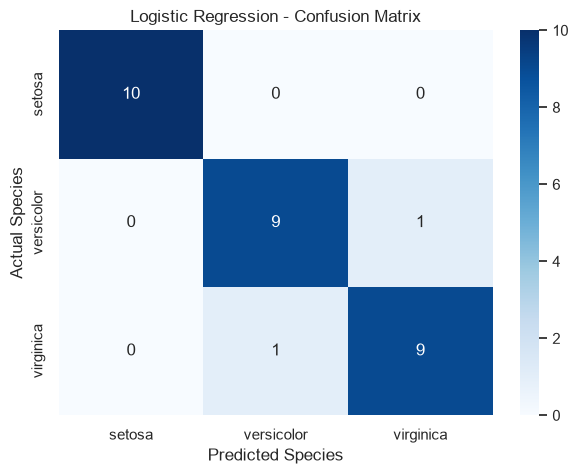

In [13]:
# Generate confusion matrix
cm_logistic = confusion_matrix(
    y_test,
    y_pred_logistic
)

# Plot confusion matrix
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_logistic,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted Species")
plt.ylabel("Actual Species")
plt.show()

## 12. Model 2 — K-Nearest Neighbors (KNN)

K-Nearest Neighbors (KNN) is a distance-based classification algorithm.

For a new observation, KNN examines the nearest observations in the
training dataset and assigns the class based on the classes of those
neighbors.

Because KNN relies on distances, feature scaling is particularly
important for this algorithm.

In [14]:
# Initialize KNN classifier
knn_model = KNeighborsClassifier(
    n_neighbors=5
)

# Train the model
knn_model.fit(X_train_scaled, y_train)

# Generate predictions
y_pred_knn = knn_model.predict(X_test_scaled)

# Calculate accuracy
knn_accuracy = accuracy_score(
    y_test,
    y_pred_knn
)

print(f"KNN Accuracy: {knn_accuracy:.4f}")

KNN Accuracy: 0.9333


In [15]:
# Display KNN classification report
print("KNN Classification Report")
print("=" * 50)

print(
    classification_report(
        y_test,
        y_pred_knn,
        target_names=iris.target_names
    )
)

KNN Classification Report
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



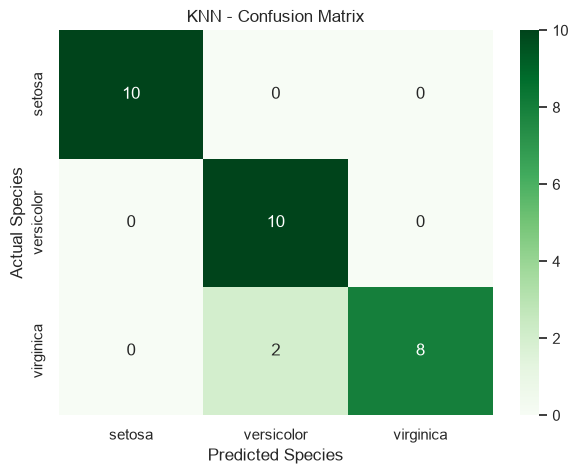

In [16]:
# Generate KNN confusion matrix
cm_knn = confusion_matrix(
    y_test,
    y_pred_knn
)

# Plot confusion matrix
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_knn,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.title("KNN - Confusion Matrix")
plt.xlabel("Predicted Species")
plt.ylabel("Actual Species")
plt.show()

## 13. Model Performance Comparison

The performance of Logistic Regression and K-Nearest Neighbors is compared
using their test-set accuracy.

Accuracy provides an overall measure of the proportion of correctly
classified observations.

However, the classification reports are also considered so that precision,
recall, and F1-score are not overlooked when selecting the final model.

In [17]:
# Create a model comparison table
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "K-Nearest Neighbors"
    ],
    "Accuracy": [
        logistic_accuracy,
        knn_accuracy
    ]
})

# Sort models by accuracy
model_comparison = model_comparison.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

# Display results
display(model_comparison)

,Model,Accuracy
0,Logistic Regression,0.933333
1,K-Nearest Neighbors,0.933333


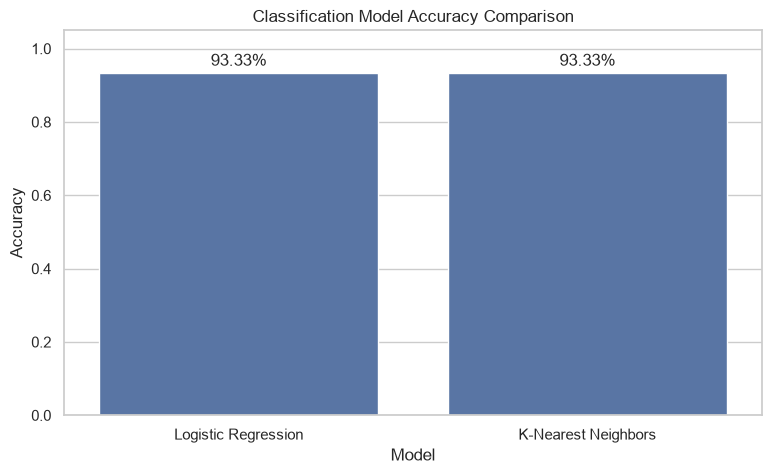

In [18]:
# Plot model accuracy comparison
plt.figure(figsize=(9, 5))

sns.barplot(
    data=model_comparison,
    x="Model",
    y="Accuracy"
)

plt.ylim(0, 1.05)
plt.title("Classification Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")

# Add accuracy labels
for index, value in enumerate(model_comparison["Accuracy"]):
    plt.text(
        index,
        value + 0.02,
        f"{value:.2%}",
        ha="center"
    )

plt.show()

## 14. Best Model Selection

The model with the highest test-set accuracy is selected as the best
performing classifier.

The final decision is based on test-set performance while also considering
the precision, recall, F1-score, and confusion matrix of each model.

The selected model provides the strongest overall classification performance
among the models evaluated in this project.

In [19]:
# Identify the best-performing model
best_model_name = model_comparison.loc[0, "Model"]
best_accuracy = model_comparison.loc[0, "Accuracy"]

print(f"Best Model: {best_model_name}")
print(f"Test Accuracy: {best_accuracy:.2%}")

Best Model: Logistic Regression
Test Accuracy: 93.33%


# Identify the best-performing model
best_model_name = model_comparison.loc[0, "Model"]
best_accuracy = model_comparison.loc[0, "Accuracy"]

print(f"Best Model: {best_model_name}")
print(f"Test Accuracy: {best_accuracy:.2%}")

## 15. Detailed Model Evaluation

To obtain a comprehensive comparison, precision, recall, and F1-score are
calculated for both classification models.

These metrics provide additional information beyond accuracy and help
evaluate how effectively each model identifies the individual Iris species.

In [20]:
# Generate detailed classification reports
logistic_report = classification_report(
    y_test,
    y_pred_logistic,
    target_names=iris.target_names,
    output_dict=True
)

knn_report = classification_report(
    y_test,
    y_pred_knn,
    target_names=iris.target_names,
    output_dict=True
)

# Create a summary table for the two models
detailed_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "K-Nearest Neighbors"
    ],
    "Accuracy": [
        logistic_report["accuracy"],
        knn_report["accuracy"]
    ],
    "Precision (Weighted)": [
        logistic_report["weighted avg"]["precision"],
        knn_report["weighted avg"]["precision"]
    ],
    "Recall (Weighted)": [
        logistic_report["weighted avg"]["recall"],
        knn_report["weighted avg"]["recall"]
    ],
    "F1-Score (Weighted)": [
        logistic_report["weighted avg"]["f1-score"],
        knn_report["weighted avg"]["f1-score"]
    ]
})

# Display the detailed comparison
display(
    detailed_comparison.style.format({
        "Accuracy": "{:.2%}",
        "Precision (Weighted)": "{:.2%}",
        "Recall (Weighted)": "{:.2%}",
        "F1-Score (Weighted)": "{:.2%}"
    })
)

,Model,Accuracy,Precision (Weighted),Recall (Weighted),F1-Score (Weighted)
0,Logistic Regression,93.33%,93.33%,93.33%,93.33%
1,K-Nearest Neighbors,93.33%,94.44%,93.33%,93.27%


## 16. Final Model Interpretation

The two classification algorithms demonstrate strong performance on the
Iris dataset.

The model comparison considers accuracy as well as weighted precision,
recall, and F1-score.

The confusion matrices provide additional insight into the individual
classification errors made by each model.

The exploratory analysis also showed that petal length and petal width
provide strong separation between the Iris species. This explains why
classification performance is high across the evaluated models.

The model with the strongest overall test-set performance is selected as
the final classifier for this project.

In [21]:
# Display the final selected model
print("Final Model Selection")
print("=" * 40)
print(f"Selected Model : {best_model_name}")
print(f"Test Accuracy  : {best_accuracy:.2%}")

Final Model Selection
Selected Model : Logistic Regression
Test Accuracy  : 93.33%


# 17. Conclusion

This project successfully implemented a complete machine learning
classification workflow for identifying Iris flower species.

The analysis began with dataset inspection and exploratory data analysis.
Feature distributions, pairwise relationships, box plots, and correlation
analysis were used to understand the characteristics of the dataset.

The analysis indicated that petal-related measurements, particularly petal
length and petal width, provide strong separation between the Iris species.

Two classification algorithms — Logistic Regression and K-Nearest
Neighbors — were trained using an 80:20 train-test split.

Both models were evaluated using:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix

The models were then compared using their test-set performance, and the
best-performing model was selected.

Overall, this project demonstrates the complete process of developing,
evaluating, and interpreting a supervised machine learning classification
model using Python and Scikit-learn.